<a href="https://colab.research.google.com/github/Luca-1221/MyMIS433/blob/main/Copy_of_assignment_IMDB_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [17]:
import pandas as pd
import numpy as np

In [18]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [19]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [20]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [21]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb['Released_Year'].value_counts()

,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [22]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
imdb[imdb['Released_Year'] == 'PG']

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933"


In [23]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value
imdb.loc[966, 'Released_Year'] = 1995
imdb.loc[966, 'Certificate'] = 'PG'
imdb.loc[966]

,966
Poster_Link,https://m.media-amazon.com/images/M/MV5BNjEzYj...
Series_Title,Apollo 13
Released_Year,1995
Certificate,PG
Runtime,140 min
Genre,"Adventure, Drama, History"
IMDB_Rating,7.6
Overview,NASA must devise a strategy to return Apollo 1...
Meta_score,77.0
Director,Ron Howard


In [24]:
# Change the data type of "Released_Year" to int
imdb['Released_Year'] = imdb['Released_Year'].astype(int)

In [25]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"

# Ensure Gross is numeric before sorting (handled in previous steps, but good to be safe)
filtered_movies = imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]

# Display the specific columns and sort
result = filtered_movies[['Series_Title', 'Released_Year', 'Certificate', 'Gross']].sort_values(by='Gross', ascending=False)
display(result)

,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [ ]:
# Does the sorting result looks right to you? What's the problem?


In [26]:
imdb['Gross'] = imdb['Gross'].str.replace(',', '', regex=False)
imdb['Gross'] = pd.to_numeric(imdb['Gross'], errors='coerce')
# Display the info again to confirm the data type change
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   int64  
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    float64
dtypes: float64(3), int64(2), object(11)
memory usage: 125.1+ KB


In [27]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"

filtered_movies = imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]

display(filtered_movies[['Series_Title', 'Released_Year', 'Certificate', 'Gross']].sort_values(by='Gross', ascending=False))

,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [28]:
# Add a new column "Runtime_min" by removing the substring ' min' in "Runtime"
# Set its data type as int

imdb['Runtime_min'] = imdb['Runtime'].str.replace(' min', '').astype(int)

# Display the first few rows to verify
display(imdb[['Series_Title', 'Runtime', 'Runtime_min']].head())

,Series_Title,Runtime,Runtime_min
0,The Shawshank Redemption,142 min,142
1,The Godfather,175 min,175
2,The Dark Knight,152 min,152
3,The Godfather: Part II,202 min,202
4,12 Angry Men,96 min,96


In [29]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
imdb['Age_Year'] = 2026 - imdb['Released_Year']
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Age_Year
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,142,32
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175,54
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152,18
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,202,52
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,96,69


In [30]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
imdb['Decade'] = (imdb['Released_Year'] // 10) * 10

# Display the count of movies per decade to verify
display(imdb['Decade'].value_counts().sort_index())

,count
Decade,
1920,11
1930,24
1940,35
1950,56
1960,73
1970,76
1980,89
1990,151
2000,237


## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

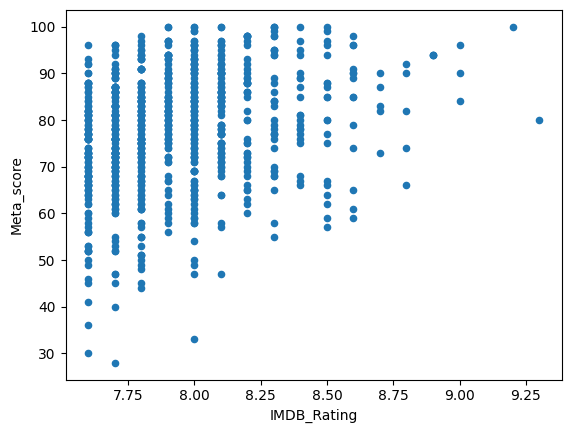

In [32]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.
imdb.plot(x='IMDB_Rating', y='Meta_score', kind='scatter')
# This scatterplot suggest that there is a corelation between meta scores and IMDB rattings.

<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

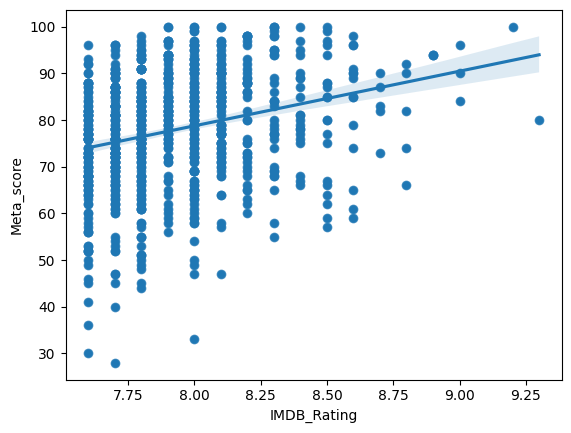

In [33]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.
imdb.plot(x='IMDB_Rating', y='Meta_score', kind='scatter')
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, order=1)

In [34]:
# Identify movies where IMDB_Rating and Meta_score (normalized) differ the most
imdb['score_diff'] = abs(imdb['IMDB_Rating'] - (imdb['Meta_score'] / 10))

# Display the top 10 movies with the largest discrepancy
surprising_movies = imdb.sort_values(by='score_diff', ascending=False).head(10)
display(surprising_movies[['Series_Title', 'IMDB_Rating', 'Meta_score', 'score_diff']])

,Series_Title,IMDB_Rating,Meta_score,score_diff
788,I Am Sam,7.7,28.0,4.9
356,Tropa de Elite,8.0,33.0,4.7
942,The Butterfly Effect,7.6,30.0,4.6
917,Seven Pounds,7.6,36.0,4.0
735,Kai po che!,7.7,40.0,3.7
957,Fear and Loathing in Las Vegas,7.6,41.0,3.5
272,Pink Floyd: The Wall,8.1,47.0,3.4
648,The Boondock Saints,7.8,44.0,3.4
677,Predator,7.8,45.0,3.3
397,Bound by Honor,8.0,47.0,3.3


<Axes: xlabel='IMDB_Rating', ylabel='Meta_score'>

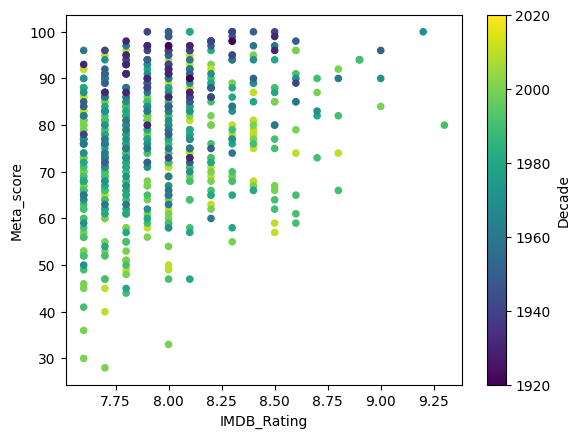

In [35]:
# In the scatterplot, use color to distinguish movies from different decades.
imdb.plot(x='IMDB_Rating', y='Meta_score', kind='scatter', c='Decade', cmap='viridis')

<Axes: xlabel='Decade'>

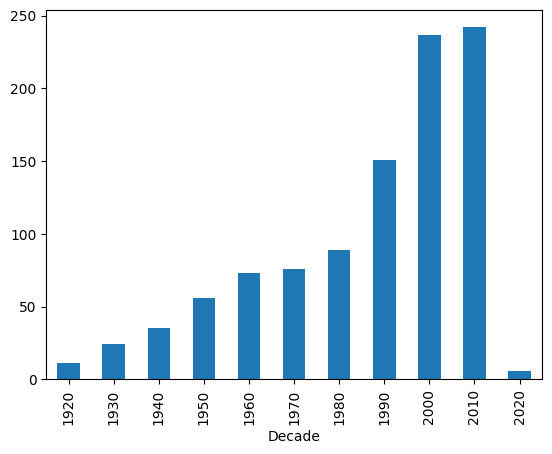

In [36]:
# Create a chart that shows how many movies fall in each decade.
imdb['Decade'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

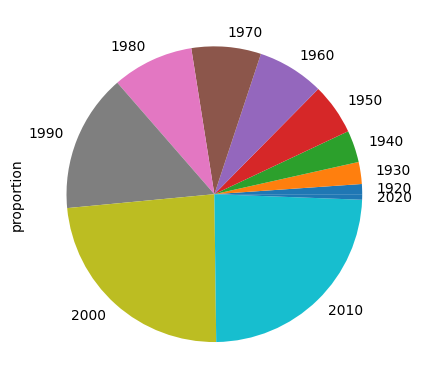

In [37]:
# Create a chart that shows the percentage of movies in each decade.
imdb['Decade'].value_counts(normalize=True).sort_index().plot(kind='pie')

<Axes: xlabel='Director'>

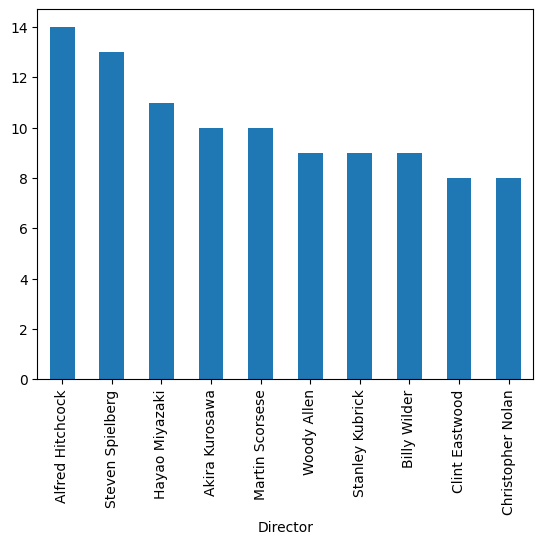

In [38]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.
imdb['Director'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='IMDB_Rating', ylabel='Gross'>

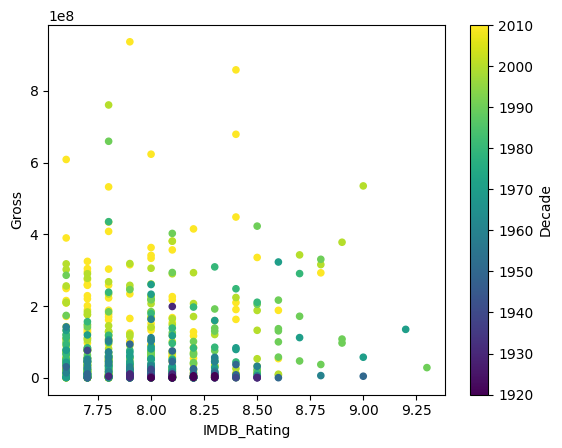

In [39]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.
imdb.plot(x='IMDB_Rating', y='Gross', kind='scatter', c='Decade', cmap='viridis')

In [40]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.
imdb['Drama'] = imdb['Genre'].str.contains('Drama').astype(int)
imdb

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,...,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Age_Year,Decade,score_diff,Drama
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,...,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,142,32,1990,1.3,1
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,...,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175,54,1970,0.8,1
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,...,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152,18,2000,0.6,1
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,...,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,202,52,1970,0.0,1
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,...,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,96,69,1950,0.6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,...,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN,115,65,1960,0.0,1
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,...,Rock Hudson,James Dean,Carroll Baker,34075,NaN,201,70,1950,0.8,1
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,...,Montgomery Clift,Deborah Kerr,Donna Reed,43374,30500000.0,118,73,1950,0.9,1
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,...,John Hodiak,Walter Slezak,William Bendix,26471,NaN,97,82,1940,0.2,1


<Axes: xlabel='Decade'>

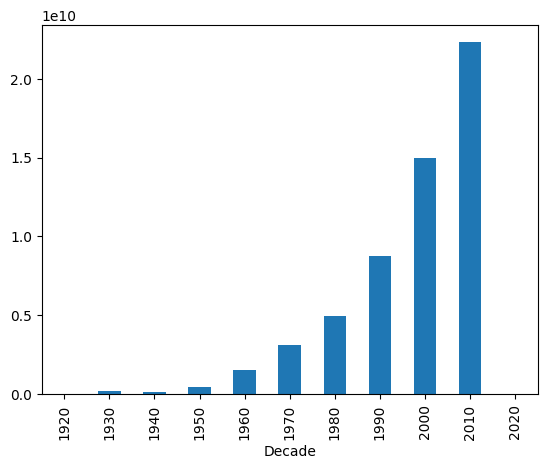

In [41]:
# Create a plot comparing gross revenue across decades.
imdb.groupby('Decade')['Gross'].sum().plot(kind='bar')

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for movies with gross over $100 million
imdb_100Mil = imdb[imdb['Gross'] > 100000000].copy()



In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Gross is numeric
imdb['Gross'] = pd.to_numeric(imdb['Gross'].astype(str).str.replace(',', ''), errors='coerce')

# Filter for movies with gross over $100 million
imdb_100Mil = imdb[imdb['Gross'] > 100000000].copy()

# Display the count of blockbuster movies found
print(f"Number of movies with gross > $100M: {len(imdb_100Mil)}")
display(imdb_100Mil.head())

Number of movies with gross > $100M: 187


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,...,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min,Age_Year,Decade,score_diff,Drama
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,...,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,175,54,1970,0.8,1
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,...,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,152,18,2000,0.6,1
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,...,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,377845905.0,201,23,2000,0.5,1
6,https://m.media-amazon.com/images/M/MV5BNGNhMD...,Pulp Fiction,1994,A,154 min,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,...,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,107928762.0,154,32,1990,0.5,1
8,https://m.media-amazon.com/images/M/MV5BMjAxMz...,Inception,2010,UA,148 min,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,...,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,292576195.0,148,16,2010,1.4,0


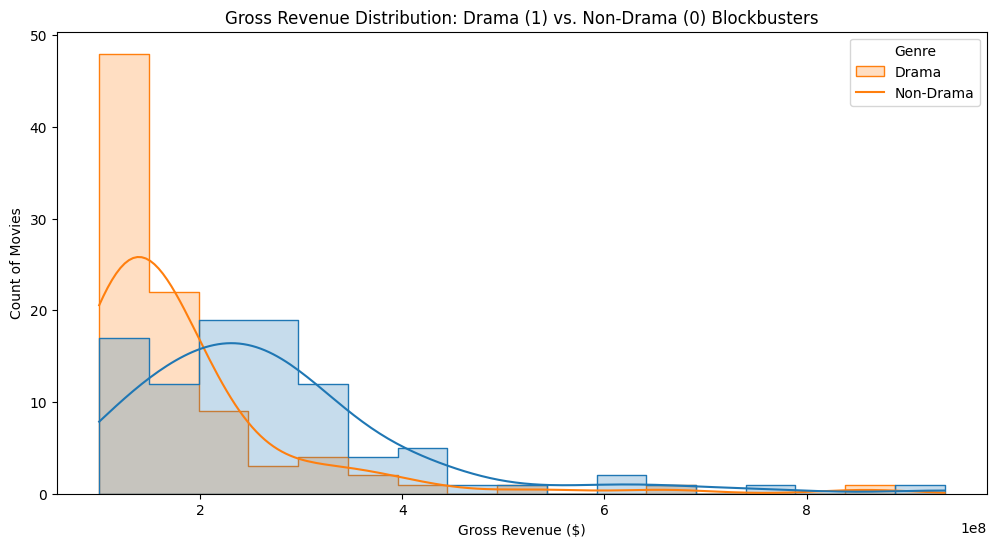

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of gross for drama vs. non-drama movies using the filtered blockbuster list
plt.figure(figsize=(12, 6))
sns.histplot(data=imdb_100Mil, x='Gross', hue='Drama', kde=True, element='step')

plt.title('Gross Revenue Distribution: Drama (1) vs. Non-Drama (0) Blockbusters')
plt.xlabel('Gross Revenue ($)')
plt.ylabel('Count of Movies')
plt.legend(title='Genre', labels=['Drama', 'Non-Drama'])
plt.show()

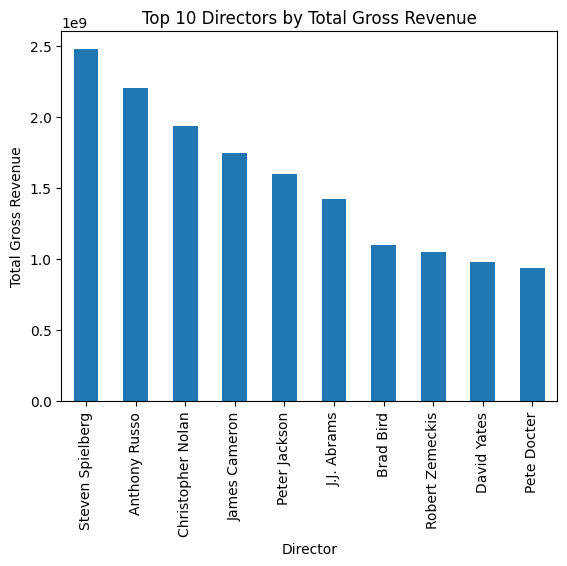

Total Gross Revenue for Steven Spielberg: $2,478,133,165.00


In [55]:
# Question 1: What is the total gross revenue of movies directed by Spielberg?
spielberg_gross = imdb[imdb['Director'] == 'Steven Spielberg']['Gross'].sum()

# Visualize Spielberg vs other top directors' total gross
top_directors_gross = imdb.groupby('Director')['Gross'].sum().sort_values(ascending=False).head(10)
top_directors_gross.plot(kind='bar', title='Top 10 Directors by Total Gross Revenue')
plt.ylabel('Total Gross Revenue')
plt.show()

print(f'Total Gross Revenue for Steven Spielberg: ${spielberg_gross:,.2f}')

In [58]:
# Question 2: What are the 10 highest rated PG films?
pg_movies = imdb[imdb['Certificate'] == 'PG']
top_10_pg = pg_movies.sort_values(by='IMDB_Rating', ascending=False).head(10)

display(top_10_pg[['Series_Title', 'IMDB_Rating', 'Released_Year', 'Director']])

,Series_Title,IMDB_Rating,Released_Year,Director
32,It's a Wonderful Life,8.6,1946,Frank Capra
100,Bacheha-Ye aseman,8.3,1997,Majid Majidi
135,Klaus,8.2,2019,Sergio Pablos
176,The Message,8.2,1976,Moustapha Akkad
178,Monty Python and the Holy Grail,8.2,1975,Terry Gilliam
219,Song of the Sea,8.1,2014,Tomm Moore
265,Dà hóng denglong gaogao guà,8.1,1991,Yimou Zhang
281,Barry Lyndon,8.1,1975,Stanley Kubrick
286,Solaris,8.1,1972,Andrei Tarkovsky
304,The Bridge on the River Kwai,8.1,1957,David Lean
